Notebook testing new interpolation method to keep long nan sequences as nans

In [11]:
from read_data import load_subject, interp_data, interp_data_new
import sys
import time
import numpy as np
from itertools import groupby
from operator import itemgetter
import matplotlib.pyplot as plt
sys.path.insert(1, '../plotter')
from plotter import plot_timeseries, plot_activity

In [12]:
df = load_subject('102')

Total structured columns generated: 54
First 10 columns: ['timestamp', 'activity_id', 'heart_rate', 'hand_temp', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z']
Reading from ../data/PAMAP2_Dataset/Protocol/subject102.dat
Loading raw subject file (this might take a few seconds because it is a massive telemetry file)...

--- RAW DATA DIAGNOSTICS FOR SUBJECT 102 ---
Total raw rows: 447,000
Total continuous tracking time: 74.59 minutes

Top 5 Columns with the Highest Percentage of Missing Data (NaNs):
heart_rate      90.873602
hand_temp        0.610515
hand_acc16_x     0.610515
hand_acc16_y     0.610515
hand_acc6_x      0.610515
dtype: float64


In [13]:
limit = 10

In [14]:
def check_nanLength(df,column):
    null_search = df[column].isnull()
    null_list = null_search[null_search].index.values
    nan_lengths = []
    if len(null_list) != 0:
        # group NaN rows by consecutive sequences
        
        for k, g in groupby(enumerate(null_list), lambda x: x[0]-x[1]):
            n_set = list(map(itemgetter(1), g))
            nan_lengths.append(len(n_set))
    

    return nan_lengths

[ 1  1  1 ... 11 16 20]
How many sequences longer than 10:
4
[11 11 16 20]
58


Text(0, 0.5, 'Count')

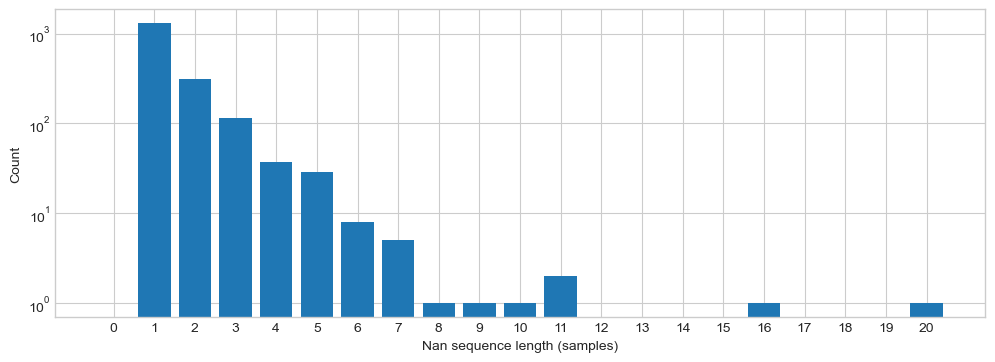

In [15]:
nan_lengths = np.array(check_nanLength(df,'hand_gyro_x'))
nan_lengths.sort()
print(nan_lengths)
print('How many sequences longer than '+str(limit)+':')
num1 = np.sum(nan_lengths>limit)
print(np.sum(num1))
long_nans = nan_lengths[-num1:]
print(long_nans)
print(np.sum(long_nans))

plt.rcParams["figure.figsize"] = (12,4)

edges = np.arange(0,max(nan_lengths)+2) - 0.5
centers = edges[:-1] + 0.5
centers = centers.astype(int)

heights,temp = np.histogram(nan_lengths,bins=edges)
plt.bar(edges[:-1]+0.5,heights)
plt.xticks(centers)
plt.yscale('log')
plt.xlabel('Nan sequence length (samples)')
plt.ylabel('Count')


In [16]:
df_interp,mask = interp_data_new(df,limit=limit,columns=['hand_gyro_x','hand_gyro_y','hand_gyro_z'],limit_area='inside',nan_bfill=True)

Selected DataFrame columns have 0.6105% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.013% NaNs!



In [17]:
np.sum(1-mask)

np.int64(174)

[11 11 16 20]
How many sequences longer than 10:
4
[11 11 16 20]
58


Text(0, 0.5, 'Count')

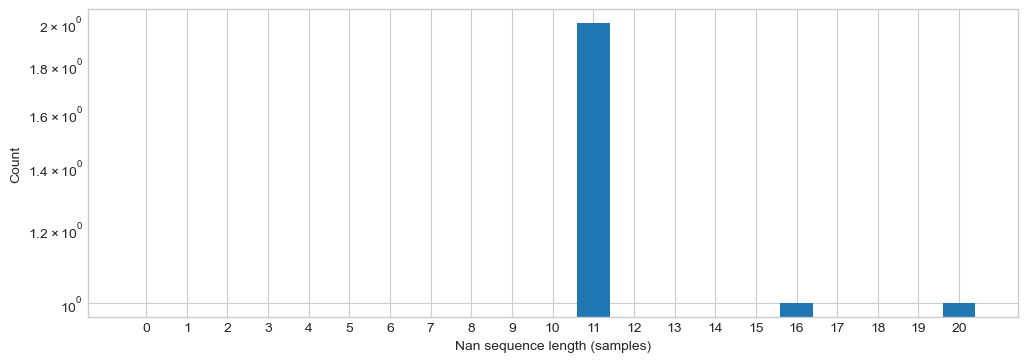

In [18]:
nan_lengths = np.array(check_nanLength(df_interp,'hand_gyro_x'))
nan_lengths.sort()
print(nan_lengths)
print('How many sequences longer than '+str(limit)+':')
num2 = np.sum(nan_lengths>limit)
print(np.sum(num2))
long_nans = nan_lengths[-num2:]
print(long_nans)
print(np.sum(long_nans))

plt.rcParams["figure.figsize"] = (12,4)

edges = np.arange(0,max(nan_lengths)+2) - 0.5
centers = edges[:-1] + 0.5
centers = centers.astype(int)

heights,temp = np.histogram(nan_lengths,bins=edges)
plt.bar(edges[:-1]+0.5,heights)
plt.xticks(centers)
plt.yscale('log')
plt.xlabel('Nan sequence length (samples)')
plt.ylabel('Count')

In [19]:
print('Method worked?')
print(num1==num2)

Method worked?
True


Using input dataframe!


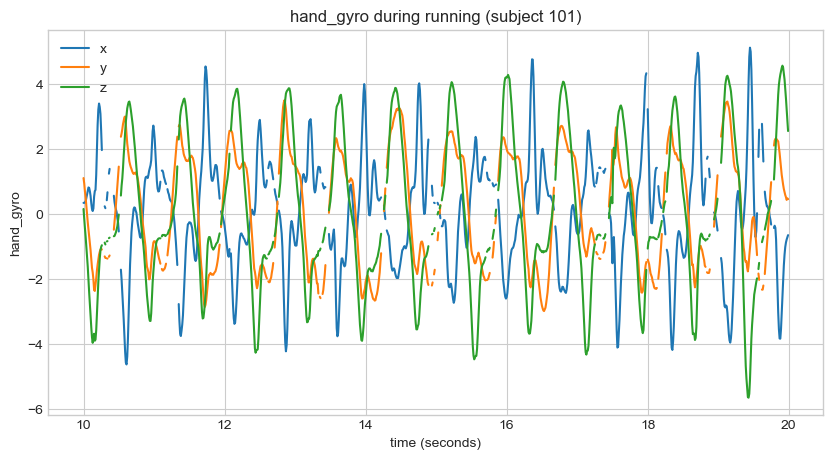

In [20]:
seg1 = plot_activity('101', 'running', sensor='hand_gyro',df=df)

and after the interpolation:

Using input dataframe!


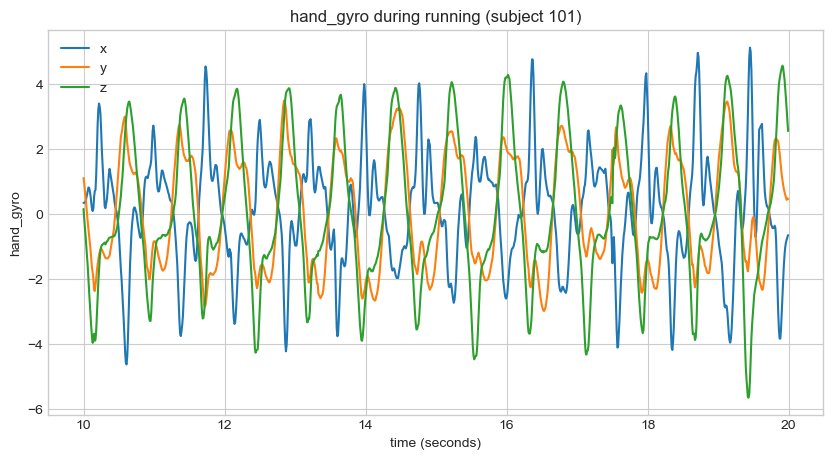

In [21]:
seg2 = plot_activity('101', 'running', sensor='hand_gyro',df=df_interp)